# A robust script to take 2D or 3D output from CESM as well as 2D or 3D ouutput from obs. and reanalysis to:plot
### 1. Zonal Averages for 1D
### 2. Lat-Lon averages for 2D
### 3. Zonal average for 3D

In [12]:
import xarray as xr
import matplotlib.pyplot as mp
import numpy as np
import glob as glob

import importlib
import general_cesm_plot_utils as mypy_utils


In [13]:
# Replace with your actual file paths and variable name

# Import



dir0 = '/glade/derecho/scratch/rneale/archive/'
dir_climo = '/glade/campaign/cgd/amp/amwg/climo/'
dir_obs = '/glade/campaign/cgd/amp/amwg/amwg_data/obs_data/'



lfcase = True
lplat_ave = True
lplatlon_ave = True
lplatpres_ave = False
mask_ocn = False


if lfcase:

    fig_pref = 'CAM7'

    dcases = {'CAM7'               : 'f.cam6_4_032.FLTHIST_ne30.cam7_dev.002',
             '0.75*lhf'           : 'f.e30_cam6_4_078.FHISTC_LTso.ne30.lhf_roughphis_SGH_grlnd28k.001',
             'qsat (T2m)'         : 'f.e30_cam6_4_078.FHISTC_LTso.ne30.ssq_T2m_roughphis_SGH_grlnd28k.001',
             'flux all (T2m)'     : 'f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_T2m_roughphis_SGH_grlnd28k.001',
             'flux all (T2m:SST)' :'f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_Tsave_roughphis_SGH_grlnd28k.001',
             'UA'                 :'f.e30_cam6_4_078.FHISTC_LTso.ne30.ocnflx2_roughphis_SGH_grlnd28k.001',
             'G&G qsat'           :'f.e30_cam6_4_078.FHISTC_LTso.ne30.baseline156_qsat.001'}

else:

    fig_pref = 'CESM3'
    
    dcases = {'156': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.156', 
              '158': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.158',
              '160': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.160', 
              '162': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.162', 
              '163': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.163',
              '164': 'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.163'}
   
    
case_names = list(dcases.keys())
cases = [v for v in dcases.values()]


#var = 'SHFLX' ; vname = 'Sensible Heat Flux'  ; vscale = 1. ; vunits = 'W/m^2' ; obs_cases = ['JRA25']
#var = 'LHFLX' ; vname = 'Latent Heat Flux'  ; vscale = 1. ; vunits = 'W/m^2' ; obs_cases = ['ERAI', 'LARYEA','WHOI']
var = 'PRECT' ; vname = 'Total Precipitation' ; vscale = 86400.*1000. ; vunits = 'mm/day'; obs_cases = ['GPCP', 'TRMM']
#var = 'TMQ' ; vname = 'Precipitable Water' ; vscale = 1. ; vunits = 'mm'; obs_cases=['NVAP']
#var = 'TAUX' ; vname = 'Zonal Surface Stress' ; vscale = 1. ; vunits = 'N/m^2'; obs_cases=['MERRA','JRA25','ERS']
#var = 'TAUY' ; vname = 'Meridonal Surface Stress' ; vscale = 1. ; vunits = 'N/m^2'; obs_cases=['MERRA','JRA25','ERS']

seas = 'ANN'

vmask_ocn = ['SHFLX','LHFLX','TMQ','PRECT','TAUX','TAUY']


cases.extend(obs_cases)
case_names.extend(obs_cases)

ncases = len(cases)


obs_set = ['GPCP','TRMM','ERAI','JRA25','MERRA','LARYEA','WHOI','NVAP','ERS','SSMI']


# Test options

if sum([lplat_ave, lplatlon_ave, lplatpres_ave]) == 1:
    print("Good - Selecting ONE plot type")
else:
    
    print("Bad - Selcting >1 plot type")
    exit()



Plotting  PRECT for the following cases
- f.cam6_4_032.FLTHIST_ne30.cam7_dev.002
- f.e30_cam6_4_078.FHISTC_LTso.ne30.lhf_roughphis_SGH_grlnd28k.001
- f.e30_cam6_4_078.FHISTC_LTso.ne30.ssq_T2m_roughphis_SGH_grlnd28k.001
- f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_T2m_roughphis_SGH_grlnd28k.001
- f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_Tsave_roughphis_SGH_grlnd28k.001
- f.e30_cam6_4_078.FHISTC_LTso.ne30.ocnflx2_roughphis_SGH_grlnd28k.001
- f.e30_cam6_4_078.FHISTC_LTso.ne30.baseline156_qsat.001
- GPCP
- TRMM

Case -  [1]  of  [9]  -  f.cam6_4_032.FLTHIST_ne30.cam7_dev.002

Case -  [2]  of  [9]  -  f.e30_cam6_4_078.FHISTC_LTso.ne30.lhf_roughphis_SGH_grlnd28k.001

Case -  [3]  of  [9]  -  f.e30_cam6_4_078.FHISTC_LTso.ne30.ssq_T2m_roughphis_SGH_grlnd28k.001

Case -  [4]  of  [9]  -  f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_T2m_roughphis_SGH_grlnd28k.001

Case -  [5]  of  [9]  -  f.e30_cam6_4_078.FHISTC_LTso.ne30.flux_all_Tsave_roughphis_SGH_grlnd28k.001

Case -  [6]  of  [9]  -  f.e30_

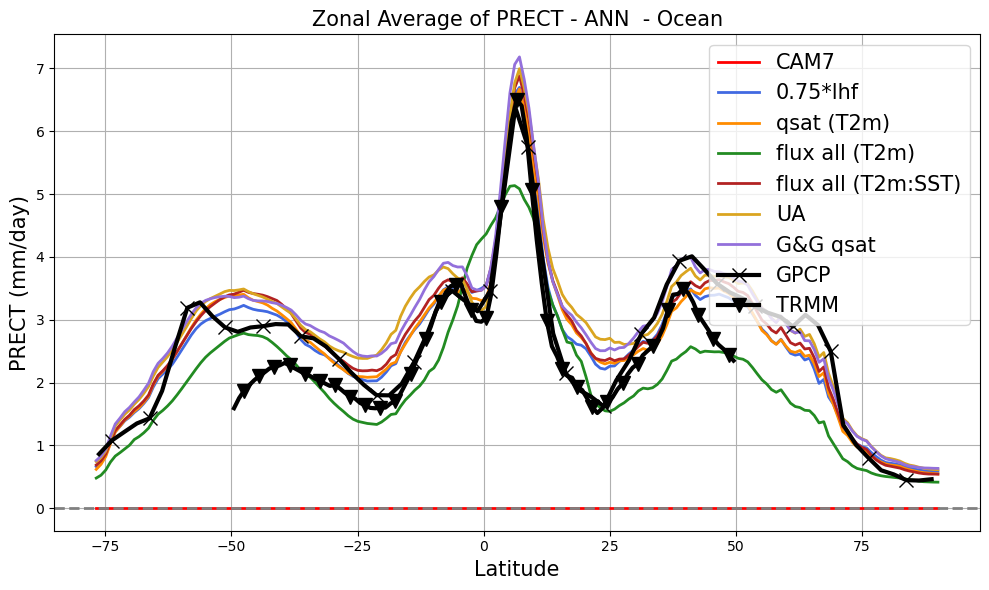

In [38]:
importlib.reload(mypy_utils) # Required because I am constantly editing scam_func.py


if lplat_ave:
    fig, ax = mp.subplots(figsize=[10, 6])    
    

if lplatlon_ave:
    nrows = 3
    ncols = 2
    fig, ax = mp.subplots(nrows=nrow, ncols=ncol, figsize=[10, 6])    
    ax = axs.flatten()

print('Plotting ',var,'for the following cases')
fcases = '\n'.join(f"- {item}" for item in cases)

print(fcases)





''' LOOP CASES '''


for icase, case in enumerate(cases):

    print('')
    print('Case - ',[icase+1],' of ',[ncases],' - ',case)
    cname = case_names[icase]
    llast_case = icase == ncases-1 # Is this the last case.


# Obs and 2 climo types file selection.
    if case in obs_set:
        case_file = dir_obs+case+'_'+seas+'_climo.nc'        
    else:
        if 'b.e30' in case:
            case_file = glob.glob(dir_climo+case+'/*/'+case+'_'+var+'_climo.nc')[0]  
        else:
            case_file = dir0+case+'/climo/'+case+'_'+seas+'_climo.nc'
            

# Open dataset
    
    ds = xr.open_dataset(case_file,decode_times = False)
    
    
# Extract variable/obs. specific information

    var_info = mypy_utils.set_var_params(vname,case)
    
    var_on_file = var_info[var][case][1] if case in obs_set else var
    vscale = var_info[var][case][0]      if case in obs_set else var_info[var]['vscale']
    vunits = var_info[var]['vunits']


  
# Select climo files (2 types - amwg/python versions)
    if ds.sizes.get('time') == 12:
        mon_index = putil.get_indexes(seas)
        ds = ds.sel(time=mon_index).mean(dim='time').squeeze()
    
    var_in = ds[var_on_file].isel(time=0) if 'time' in ds[var_on_file].dims else ds[var_on_file]
    var_in = var_in*vscale


# Masking option.    
    if icase == 0:  
        if 'b.e30' in case:
            case_file = glob.glob(dir_climo+case+'/*/'+case+'_LANDFRAC_climo.nc')[0]  
            
            dlfrac = xr.open_dataset(case_file,decode_times = False)
            lmask = dlfrac['LANDFRAC'].isel(time=0) 
        else:
            lmask =  ds['LANDFRAC'].isel(time=0) if 'time' in ds['LANDFRAC'].dims else ds['LANDFRAC']

    if var in vmask_ocn:
      
        mask_ocn = True
        lmaski = lmask.interp_like(var_in)
        var_in = var_in.where(lmaski < 0.1)  # or lsm == False if it's a boolean mask
        

# Anomalies from icase = 0?

    if icase == 0 and lanom_plot: 
        var_save = var_in
    else :
        var_plot = var_in.interp_like(var_save)-var_save
    
# Plotting options
    
    if lplat_ave:
        zonal_mean = var_plot.mean(dim='lon', skipna=True)
        params_lat = mypy_utils.set_params_lat(icase,obs_set)
        mypy_utils.plot_lat(ax,fig,zonal_mean,vunits,cname,seas,mask_ocn,llast_case,params_lat)

    if lplatlon_ave:var_plo
        params_lat = mypy_utils.set_params_laton(icase,ncases,case,cases,obs_set,lanom_plot)
        mypy_utils.plot_lat(ax[icase],fig,var_plot,vunits,cname,seas,mask_ocn,llast_case,params_lat)

    if lplatpres_ave:
        zonal_mean = var_plot.mean(dim='lon', skipna=True)
        params_lat = mypy_utils.set_params_latpres(icase,ncases,case,cases,obs_set)
       
        
        mypy_utils.plot_lat(ax[icase]x,fig,var_plot,vunits,cname,seas,mask_ocn,llast_case,params_lat)
        
    
    
    


